## 1. Imports and setup

In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import json
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from implied_volatility_diffusion import (
    SurfaceNormalizer,
    UnifiedGrid,
    load_config,
    merge_config,
    merge_config_files,
)
from implied_volatility_diffusion.data.historical_data_smoothing_interpolation import (
    load_cleaned_data,
)
from implied_volatility_diffusion.data.historical_sabr_interpolation import (
    build_historical_sabr_surface,
)
from implied_volatility_diffusion.synthetic.heston import (
    implied_vol_surfaces_heston_sequential_lhs,
    load_heston_iv_surface_config,
)
from implied_volatility_diffusion.synthetic.sabr import (
    implied_vol_surfaces_sabr_sequential_lhs,
)

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 110, "axes.grid": False})

In [25]:
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CFG_DIR = REPO_ROOT / "config"
DATA_DIR = REPO_ROOT / "data"
PROCESSED_PARQUET = DATA_DIR / "processed" / "processed.parquet"

OUT_ROOT = DATA_DIR / "processed" / "forecasting_dataset"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

In [26]:
GRID = UnifiedGrid.load(CFG_DIR / "unified_iv_grid.yaml")
K_AXIS = GRID.log_moneyness
TAU_AXIS = GRID.tau
KK, TT = GRID.meshgrid()
print(
    "unified grid:",
    GRID.shape,
    "  k in",
    (float(K_AXIS[0]), float(K_AXIS[-1])),
    "  tau in",
    (float(TAU_AXIS[0]), float(TAU_AXIS[-1])),
)

SAMPLE_DATE = pd.Timestamp("2021-06-17")
HIST_DATE_FROM = pd.Timestamp("2019-01-01")
HIST_DATE_TO = pd.Timestamp("2023-12-31")
SEED = 42

# Risk-neutral assumptions used for the historic SABR calibration
HIST_R = 0.03
HIST_Q = 0.0
HIST_BETA = 0.5

unified grid: (41, 40)   k in (-0.5, 0.5000000000000003)   tau in (0.05, 2.000000000000001)


## Historic data pipeline

In [27]:
t0 = time.perf_counter()
df = load_cleaned_data(PROCESSED_PARQUET)
print(f"loaded {len(df):,} rows in {time.perf_counter() - t0:.1f}s")
print("quote date span:", df["quote_date"].min().date(), "->", df["quote_date"].max().date())

loaded 15,409,923 rows in 7.3s
quote date span: 2019-01-02 -> 2023-12-29


In [6]:
unique_dates = pd.DatetimeIndex(np.sort(df["quote_date"].dropna().unique()))
in_range = (unique_dates >= HIST_DATE_FROM) & (unique_dates <= HIST_DATE_TO)
window_dates = unique_dates[in_range]
if len(window_dates) == 0:
    raise ValueError(f"No quote dates in [{HIST_DATE_FROM.date()}, {HIST_DATE_TO.date()}]")
if SAMPLE_DATE not in window_dates:
    raise ValueError(f"Sample date {SAMPLE_DATE.date()} not present in cleaned dataset.")
print(f"historic window: {len(window_dates)} days from {window_dates[0].date()} to {window_dates[-1].date()}")

historic window: 1248 days from 2019-01-02 to 2023-12-29


In [7]:
hist_results: dict[pd.Timestamp, object] = {}
surfaces_collected: list[np.ndarray] = []
dates_collected: list[pd.Timestamp] = []
quote_counts_collected: list[int] = []
n_expiries_collected: list[int] = []
spot_collected: list[float] = []
skipped_dates: list[tuple[pd.Timestamp, str]] = []

t0 = time.perf_counter()
n_days = int(len(window_dates))
for i, d in enumerate(window_dates):
    day_df = df[df["quote_date"] == d]
    try:
        res = build_historical_sabr_surface(
            day_df,
            k_grid=K_AXIS,
            tau_grid=TAU_AXIS,
            r=HIST_R,
            q=HIST_Q,
            beta=HIST_BETA,
        )
    except Exception as exc:  # noqa: BLE001
        skipped_dates.append((d, f"{type(exc).__name__}: {exc}"))
        continue
    surf = res.surface
    if not np.all(np.isfinite(surf)):
        skipped_dates.append((d, "non-finite cells in calibrated surface"))
        continue

    hist_results[d] = res
    surfaces_collected.append(surf)
    dates_collected.append(d)
    quote_counts_collected.append(len(res.day_sub))
    n_expiries_collected.append(int(res.expiry_taus.size))
    spot_collected.append(float(res.spot))

    if (i + 1) % 50 == 0 or (i + 1) == n_days:
        rate = (i + 1) / max(time.perf_counter() - t0, 1e-9)
        eta = (n_days - (i + 1)) / max(rate, 1e-9)
        print(
            f"  [{i + 1:>4d}/{n_days}] kept={len(surfaces_collected):>4d}  "
            f"skipped={len(skipped_dates):>3d}  rate={rate:.1f} d/s  eta={eta:.0f}s"
        )

if not surfaces_collected:
    raise RuntimeError("Historic SABR pipeline produced no usable surfaces.")
if SAMPLE_DATE not in hist_results:
    fallback = min(dates_collected, key=lambda d: abs((d - SAMPLE_DATE).days))
    print(f"warning: sample date {SAMPLE_DATE.date()} not usable; fallback {fallback.date()}")
    SAMPLE_DATE = fallback

hist_stack = np.stack(surfaces_collected, axis=0)
hist_dates = pd.DatetimeIndex(dates_collected)
hist_quote_counts = np.asarray(quote_counts_collected, dtype=int)
hist_n_expiries = np.asarray(n_expiries_collected, dtype=int)
hist_spot = np.asarray(spot_collected, dtype=float)
hist_sample = hist_results[SAMPLE_DATE]
print(
    f"historic SABR pipeline: kept {hist_stack.shape[0]}/{n_days} days "
    f"(skipped {len(skipped_dates)}) in {time.perf_counter() - t0:.1f}s"
)

  [  50/1248] kept=  50  skipped=  0  rate=4.3 d/s  eta=279s
  [ 100/1248] kept= 100  skipped=  0  rate=4.5 d/s  eta=258s
  [ 150/1248] kept= 150  skipped=  0  rate=4.5 d/s  eta=245s
  [ 200/1248] kept= 200  skipped=  0  rate=4.5 d/s  eta=233s
  [ 250/1248] kept= 250  skipped=  0  rate=4.4 d/s  eta=225s
  [ 300/1248] kept= 300  skipped=  0  rate=4.3 d/s  eta=219s
  [ 350/1248] kept= 350  skipped=  0  rate=4.4 d/s  eta=206s
  [ 400/1248] kept= 400  skipped=  0  rate=4.4 d/s  eta=192s
  [ 450/1248] kept= 450  skipped=  0  rate=4.4 d/s  eta=180s
  [ 500/1248] kept= 500  skipped=  0  rate=4.5 d/s  eta=168s
  [ 550/1248] kept= 550  skipped=  0  rate=4.5 d/s  eta=157s
  [ 600/1248] kept= 600  skipped=  0  rate=4.4 d/s  eta=146s
  [ 650/1248] kept= 650  skipped=  0  rate=4.4 d/s  eta=136s
  [ 700/1248] kept= 700  skipped=  0  rate=4.4 d/s  eta=126s
  [ 750/1248] kept= 750  skipped=  0  rate=4.3 d/s  eta=116s
  [ 800/1248] kept= 800  skipped=  0  rate=4.3 d/s  eta=104s
  [ 850/1248] kept= 850 

## Synthetic Heston-COS surface - Unified grid

In [8]:
HESTON_PATHS = 4
HESTON_STEPS = 120

heston_cfg_raw = load_heston_iv_surface_config(CFG_DIR)
heston_cfg = GRID.with_config(heston_cfg_raw)

t0 = time.perf_counter()
heston_params, heston_m, heston_tau, heston_iv_native = implied_vol_surfaces_heston_sequential_lhs(
    heston_cfg,
    n_samples=HESTON_PATHS,
    n_batches=1,
    n_steps=HESTON_STEPS,
    seed=SEED,
)
print(f"Heston sequential LHS: {heston_iv_native.shape} in {time.perf_counter() - t0:.1f}s")

Heston sequential LHS: (4, 120, 41, 40) in 508.4s


In [9]:
# --- Heston regime sweep -----------------------------------------------------
# Generate additional surfaces under explicit regime presets (skew, smile,
# high-vol, low-vol) so the diffusion model sees a much wider distribution of
# IV shapes than the single base config delivers. Each preset overrides the
# Heston parameter ranges and is then re-projected onto the unified grid via
# `GRID.with_config`. We re-use the same `n_steps` so the resulting blocks can
# be concatenated along the path axis without padding.
HESTON_REGIMES: dict[str, Path] = {
    "skew": CFG_DIR / "heston_goal_skew.yaml",
    "smile": CFG_DIR / "heston_goal_smile.yaml",
    "high_vol": CFG_DIR / "heston_goal_high_vol.yaml",
    "low_vol": CFG_DIR / "heston_goal_low_vol.yaml",
}
HESTON_REGIME_PATHS = 3  # LHS draws per regime (kept small: COS pricer is heavy)

heston_regime_stacks: list[np.ndarray] = [heston_iv_native]
heston_regime_labels: list[str] = ["base"] * heston_iv_native.shape[0]
heston_regime_param_blocks: list[np.ndarray] = [heston_params]

for r_idx, (regime_name, regime_yaml) in enumerate(HESTON_REGIMES.items()):
    overrides = load_config(regime_yaml)
    regime_raw = merge_config(heston_cfg_raw, overrides)
    regime_cfg = GRID.with_config(regime_raw)
    t_reg = time.perf_counter()
    r_params, _, _, r_iv = implied_vol_surfaces_heston_sequential_lhs(
        regime_cfg,
        n_samples=HESTON_REGIME_PATHS,
        n_batches=1,
        n_steps=HESTON_STEPS,
        seed=SEED + 11 + r_idx,
    )
    r_finite_mask = np.isfinite(r_iv).all(axis=(-1, -2)).all(axis=-1)
    if not r_finite_mask.all():
        kept = int(r_finite_mask.sum())
        print(f"  Heston regime '{regime_name}': dropped {r_iv.shape[0] - kept} non-finite path(s)")
        r_iv = r_iv[r_finite_mask]
        r_params = r_params[r_finite_mask]
    if r_iv.shape[0] == 0:
        print(f"  Heston regime '{regime_name}': skipped (no finite paths).")
        continue
    heston_regime_stacks.append(r_iv)
    heston_regime_labels.extend([regime_name] * r_iv.shape[0])
    heston_regime_param_blocks.append(r_params)
    print(f"  Heston regime '{regime_name}': {r_iv.shape}  in {time.perf_counter() - t_reg:.1f}s")

heston_stack = np.concatenate(heston_regime_stacks, axis=0)
heston_params = np.concatenate(heston_regime_param_blocks, axis=0)
heston_regime_array = np.asarray(heston_regime_labels)
print(f"Heston pooled stack: {heston_stack.shape}  (regimes: base + {len(HESTON_REGIMES)} presets)")
heston_sample = heston_stack[0, 0]
heston_raw_sample = heston_iv_native[0, 0]

  Heston regime 'skew': (3, 120, 41, 40)  in 392.0s
  Heston regime 'smile': (3, 120, 41, 40)  in 377.3s
  Heston regime 'high_vol': (3, 120, 41, 40)  in 390.4s
  Heston regime 'low_vol': (3, 120, 41, 40)  in 358.6s
Heston pooled stack: (16, 120, 41, 40)  (regimes: base + 4 presets)


## Synthetic SABR surface - Unified grid

In [10]:
SABR_PATHS = 16
SABR_STEPS = 120

sabr_cfg_raw = merge_config_files(CFG_DIR / "sabr_iv_surface.yaml")
sabr_cfg = GRID.with_config(sabr_cfg_raw)

t0 = time.perf_counter()
sabr_params, sabr_m, sabr_tau, sabr_iv_native = implied_vol_surfaces_sabr_sequential_lhs(
    sabr_cfg,
    n_samples=SABR_PATHS,
    n_batches=1,
    n_steps=SABR_STEPS,
    seed=SEED,
)
print(f"SABR sequential LHS: {sabr_iv_native.shape} in {time.perf_counter() - t0:.1f}s")

# --- SABR regime sweep -------------------------------------------------------
# Hagan-SABR is closed-form so we can be more aggressive with extra regimes.
# Overrides target distinct shape families: equity-style negative skew, soft
# symmetric smile, high-vol-of-vol curvature, and a low-vol regime.
SABR_REGIMES: dict[str, dict] = {
    "skew": {"sabr_ranges": {"alpha": [0.10, 0.40], "rho": [-0.95, -0.55], "nu": [0.40, 0.95]}},
    "smile": {"sabr_ranges": {"alpha": [0.15, 0.45], "rho": [-0.15, 0.15], "nu": [0.50, 1.10]}},
    "high_vol": {"sabr_ranges": {"alpha": [0.30, 0.60], "rho": [-0.60, 0.10], "nu": [0.40, 1.10]}},
    "low_vol": {"sabr_ranges": {"alpha": [0.03, 0.12], "rho": [-0.50, 0.10], "nu": [0.05, 0.40]}},
}
SABR_REGIME_PATHS = 8

sabr_regime_stacks: list[np.ndarray] = [sabr_iv_native]
sabr_regime_labels: list[str] = ["base"] * sabr_iv_native.shape[0]
sabr_regime_param_blocks: list[np.ndarray] = [sabr_params]

for r_idx, (regime_name, overrides) in enumerate(SABR_REGIMES.items()):
    regime_raw = merge_config(sabr_cfg_raw, overrides)
    regime_cfg = GRID.with_config(regime_raw)
    t_reg = time.perf_counter()
    r_params, _, _, r_iv = implied_vol_surfaces_sabr_sequential_lhs(
        regime_cfg,
        n_samples=SABR_REGIME_PATHS,
        n_batches=1,
        n_steps=SABR_STEPS,
        seed=SEED + 21 + r_idx,
    )
    r_finite_mask = np.isfinite(r_iv).all(axis=(-1, -2)).all(axis=-1)
    if not r_finite_mask.all():
        kept = int(r_finite_mask.sum())
        print(f"  SABR regime '{regime_name}': dropped {r_iv.shape[0] - kept} non-finite path(s)")
        r_iv = r_iv[r_finite_mask]
        r_params = r_params[r_finite_mask]
    if r_iv.shape[0] == 0:
        print(f"  SABR regime '{regime_name}': skipped (no finite paths).")
        continue
    sabr_regime_stacks.append(r_iv)
    sabr_regime_labels.extend([regime_name] * r_iv.shape[0])
    sabr_regime_param_blocks.append(r_params)
    print(f"  SABR regime '{regime_name}': {r_iv.shape}  in {time.perf_counter() - t_reg:.1f}s")

sabr_stack = np.concatenate(sabr_regime_stacks, axis=0)
sabr_params = np.concatenate(sabr_regime_param_blocks, axis=0)
sabr_regime_array = np.asarray(sabr_regime_labels)
print(f"SABR pooled stack: {sabr_stack.shape}  (regimes: base + {len(SABR_REGIMES)} presets)")
sabr_sample = sabr_stack[0, 0]
sabr_raw_sample = sabr_iv_native[0, 0]

SABR sequential LHS: (16, 120, 41, 40) in 16.2s
  SABR regime 'skew': (8, 120, 41, 40)  in 8.2s
  SABR regime 'smile': (8, 120, 41, 40)  in 8.1s
  SABR regime 'high_vol': (8, 120, 41, 40)  in 8.1s
  SABR regime 'low_vol': (8, 120, 41, 40)  in 8.1s
SABR pooled stack: (48, 120, 41, 40)  (regimes: base + 4 presets)


## Fit per-pixel normalizer on data

In [11]:
heston_flat = heston_stack.reshape(-1, *GRID.shape)
sabr_flat = sabr_stack.reshape(-1, *GRID.shape)

n_hist = int(hist_stack.shape[0])
n_heston = int(heston_flat.shape[0])
n_sabr = int(sabr_flat.shape[0])
n_total = n_hist + n_heston + n_sabr

combined_stack = np.concatenate([hist_stack, heston_flat, sabr_flat], axis=0)
source_ids = np.concatenate(
    [
        np.full(n_hist, 0, dtype=np.int8),
        np.full(n_heston, 1, dtype=np.int8),
        np.full(n_sabr, 2, dtype=np.int8),
    ]
)
source_labels = {0: "historic", 1: "heston", 2: "sabr"}
normalizer = SurfaceNormalizer(grid_shape=GRID.shape).fit(combined_stack)

min_pixel_fits = int(normalizer.count.min())
max_pixel_fits = int(normalizer.count.max())
min_coverage = min_pixel_fits / max(n_total, 1)
assert min_pixel_fits > 0, "at least one pixel never received a finite training sample"
print(f"\npooled training stack: {combined_stack.shape}  (hist={n_hist}, heston={n_heston}, sabr={n_sabr})")
print(
    f"  per-pixel fit count range: ({min_pixel_fits}, {max_pixel_fits})  min coverage = {min_coverage:.1%} of N_total"
)
print(f"  μ (mean log σ) range  : [{float(normalizer.mean.min()):+.4f}, {float(normalizer.mean.max()):+.4f}]")
print(f"  σ* (std log σ) range  : [{float(normalizer.std.min()):.4f}, {float(normalizer.std.max()):.4f}]")


pooled training stack: (8928, 41, 40)  (hist=1248, heston=1920, sabr=5760)
  per-pixel fit count range: (8928, 8928)  min coverage = 100.0% of N_total
  μ (mean log σ) range  : [-3.2083, -2.0270]
  σ* (std log σ) range  : [0.9700, 1.5377]


In [12]:
hist_z = normalizer.transform(hist_stack)
heston_z = normalizer.transform(heston_flat).reshape(heston_stack.shape)
sabr_z = normalizer.transform(sabr_flat).reshape(sabr_stack.shape)

hist_denorm = normalizer.inverse_transform(hist_z)
heston_denorm = normalizer.inverse_transform(heston_z.reshape(-1, *GRID.shape)).reshape(heston_stack.shape)
sabr_denorm = normalizer.inverse_transform(sabr_z.reshape(-1, *GRID.shape)).reshape(sabr_stack.shape)

hist_idx_sample = int(np.where(hist_dates == SAMPLE_DATE)[0][0])
hist_sample_z = hist_z[hist_idx_sample]
hist_sample_denorm = hist_denorm[hist_idx_sample]
heston_sample_z = heston_z[0, 0]
heston_sample_denorm = heston_denorm[0, 0]
sabr_sample_z = sabr_z[0, 0]
sabr_sample_denorm = sabr_denorm[0, 0]

# Roundtrip fidelity
for name, a, b in [
    ("historic", hist_stack, hist_denorm),
    ("heston", heston_stack, heston_denorm),
    ("sabr", sabr_stack, sabr_denorm),
]:
    diff = np.abs(a - b)
    print(f"roundtrip |σ − denorm(norm(σ))|  [{name:8s}]  max = {np.nanmax(diff):.2e}   mean = {np.nanmean(diff):.2e}")

combined_z = np.concatenate(
    [
        hist_z.reshape(-1, *GRID.shape),
        heston_z.reshape(-1, *GRID.shape),
        sabr_z.reshape(-1, *GRID.shape),
    ],
    axis=0,
)

# print("\nz-score diagnostics on the GLOBAL pool (expect mean ≈ 0, std ≈ 1):")
# print(f"  combined   N={combined_z.shape[0]:>5d}   mean = {combined_z.mean():+.4f}   std = {combined_z.std():.4f}")
# print(f"  historic   N={hist_z.shape[0]:>5d}   mean = {hist_z.mean():+.4f}   std = {hist_z.std():.4f}")
# print(f"  heston     N={heston_z.reshape(-1, *GRID.shape).shape[0]:>5d}   mean = {heston_z.mean():+.4f}   std = {heston_z.std():.4f}")
# print(f"  sabr       N={sabr_z.reshape(-1, *GRID.shape).shape[0]:>5d}   mean = {sabr_z.mean():+.4f}   std = {sabr_z.std():.4f}")

roundtrip |σ − denorm(norm(σ))|  [historic]  max = 8.88e-16   mean = 1.37e-17
roundtrip |σ − denorm(norm(σ))|  [heston  ]  max = 2.22e-16   mean = 2.54e-17
roundtrip |σ − denorm(norm(σ))|  [sabr    ]  max = 8.33e-17   mean = 5.22e-18


## Save with sequential layout

In [13]:
hist_dir = OUT_ROOT / "historical"
hist_dir.mkdir(parents=True, exist_ok=True)
np.save(hist_dir / "surfaces.npy", hist_stack)
np.save(hist_dir / "surfaces_normalized.npy", hist_z)
np.save(hist_dir / "dates.npy", np.asarray(hist_dates.values, dtype="datetime64[D]"))
np.save(hist_dir / "quote_counts.npy", hist_quote_counts)
np.save(hist_dir / "n_expiries_calibrated.npy", hist_n_expiries)
np.save(hist_dir / "spot.npy", hist_spot)

hist_meta = {
    "source": "historical_spx",
    "dataset": str(PROCESSED_PARQUET.relative_to(REPO_ROOT)),
    "pipeline": [
        "filter_day_for_surface (k, tau, iv, vega bounds)",
        "group quotes by expiry",
        "per-expiry Hagan-SABR calibration of (alpha, rho, nu) with fixed beta",
        "evaluate SABR lognormal closed-form on the unified (k, tau) grid (interpolates across strikes, extrapolates across maturities via nearest-expiry slice)",
        "per-pixel log-sigma z-score normalization (shared normalizer)",
    ],
    "sabr": {"beta": HIST_BETA, "r": HIST_R, "q": HIST_Q},
    "axis_order": ["day", "k", "tau"],
    "n_days": int(len(hist_dates)),
    "n_days_requested": int(len(window_dates)),
    "n_days_skipped": int(len(skipped_dates)),
    "date_range_requested": [str(HIST_DATE_FROM.date()), str(HIST_DATE_TO.date())],
    "sample_date": str(SAMPLE_DATE.date()),
    "sample_date_index": int(hist_idx_sample),
    "quote_date_range": [str(hist_dates[0].date()), str(hist_dates[-1].date())],
}
(hist_dir / "metadata.json").write_text(json.dumps(hist_meta, indent=2), encoding="utf-8")

867

In [14]:
heston_dir = OUT_ROOT / "heston"
heston_dir.mkdir(parents=True, exist_ok=True)
heston_dt = float((heston_cfg.get("sequential_ivs") or {}).get("dt", 1.0 / 252.0))
heston_step_sec = np.arange(HESTON_STEPS, dtype=float) * heston_dt * 365.0
np.save(heston_dir / "surfaces.npy", heston_stack)
np.save(heston_dir / "surfaces_normalized.npy", heston_z)
np.save(heston_dir / "params.npy", heston_params)
np.save(heston_dir / "step_days.npy", heston_step_sec)
np.save(heston_dir / "regime_labels.npy", heston_regime_array)

heston_meta = {
    "source": "synthetic_heston",
    "config": str((CFG_DIR / "heston_iv_surface.yaml").relative_to(REPO_ROOT)),
    "pipeline": [
        "Latin Hypercube sample of Heston (v0, rho, sigma_v, theta, kappa, r) with Feller clip",
        "Milstein integration of (S, v) under the risk-neutral measure",
        "Heston-COS European call prices on the unified (k, tau) grid at each step",
        "Jäckel implied-volatility inversion",
        "arbitrage guard (repair policy)",
        "per-pixel log-sigma z-score normalization (shared normalizer)",
    ],
    "param_order": ["v0", "rho", "sigma", "theta", "kappa", "r"],
    "axis_order": ["path", "step", "k", "tau"],
    "n_paths": int(heston_stack.shape[0]),
    "n_paths_base": int(HESTON_PATHS),
    "n_paths_per_regime": int(HESTON_REGIME_PATHS),
    "n_steps": int(HESTON_STEPS),
    "dt_years": heston_dt,
    "seed": int(SEED),
    "regimes": ["base"] + list(HESTON_REGIMES.keys()),
    "regime_counts": {
        name: int(np.sum(heston_regime_array == name)) for name in (["base"] + list(HESTON_REGIMES.keys()))
    },
}
(heston_dir / "metadata.json").write_text(json.dumps(heston_meta, indent=2), encoding="utf-8")

984

In [15]:
sabr_dir = OUT_ROOT / "sabr"
sabr_dir.mkdir(parents=True, exist_ok=True)
sabr_dt = float((sabr_cfg.get("sequential_ivs") or {}).get("dt", 1.0 / 252.0))
sabr_step_sec = np.arange(SABR_STEPS, dtype=float) * sabr_dt * 365.0
np.save(sabr_dir / "surfaces.npy", sabr_stack)
np.save(sabr_dir / "surfaces_normalized.npy", sabr_z)
np.save(sabr_dir / "params.npy", sabr_params)
np.save(sabr_dir / "step_days.npy", sabr_step_sec)
np.save(sabr_dir / "regime_labels.npy", sabr_regime_array)

sabr_meta = {
    "source": "synthetic_sabr",
    "config": str((CFG_DIR / "sabr_iv_surface.yaml").relative_to(REPO_ROOT)),
    "pipeline": [
        "Latin Hypercube sample of SABR (alpha, rho, nu) with fixed beta",
        "SABR SDE Euler step for (S, alpha) under the risk-neutral measure",
        "Hagan lognormal implied vol closed-form on the unified (k, tau) grid at each step",
        "arbitrage guard (repair policy)",
        "per-pixel log-sigma z-score normalization (shared normalizer)",
    ],
    "param_order": ["alpha", "rho", "nu"],
    "beta": float((sabr_cfg.get("sabr") or {}).get("beta", 0.5)),
    "axis_order": ["path", "step", "k", "tau"],
    "n_paths": int(sabr_stack.shape[0]),
    "n_paths_base": int(SABR_PATHS),
    "n_paths_per_regime": int(SABR_REGIME_PATHS),
    "n_steps": int(SABR_STEPS),
    "dt_years": sabr_dt,
    "seed": int(SEED),
    "regimes": ["base"] + list(SABR_REGIMES.keys()),
    "regime_counts": {name: int(np.sum(sabr_regime_array == name)) for name in (["base"] + list(SABR_REGIMES.keys()))},
}
(sabr_dir / "metadata.json").write_text(json.dumps(sabr_meta, indent=2), encoding="utf-8")

904

In [16]:
normalizer_path = OUT_ROOT / "normalizer.npz"
normalizer.save(normalizer_path)

manifest = {
    "sample_date": str(SAMPLE_DATE.date()),
    "grid": {
        "shape": list(GRID.shape),
        "config": str((CFG_DIR / "unified_iv_grid.yaml").relative_to(REPO_ROOT)),
    },
    "normalizer": {
        "path": str(normalizer_path.relative_to(REPO_ROOT)),
        "fit_sample_counts": {
            "historic": int(n_hist),
            "heston": int(n_heston),
            "sabr": int(n_sabr),
            "total": int(n_total),
        },
    },
    "sources": {
        "historical": str(hist_dir.relative_to(REPO_ROOT)),
        "heston": str(heston_dir.relative_to(REPO_ROOT)),
        "sabr": str(sabr_dir.relative_to(REPO_ROOT)),
    },
    "combined_training_stack_shape": list(combined_stack.shape),
}
(OUT_ROOT / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")

609

## Plot the sample for 2021-06-17

In [28]:
ELEV, AZIM = 25.0, -55.0
CMAP_IV = "turbo"
CMAP_Z = "coolwarm"


@dataclass
class SampleBundle:
    name: str  # "historic" / "heston" / "sabr"
    title: str
    raw_mode: str  # "scatter" or "surface"
    raw_k: np.ndarray | None
    raw_tau: np.ndarray | None
    raw_iv: np.ndarray  # (N,) for scatter, (I, J) for surface
    smoothed: np.ndarray  # (I, J) on unified grid
    normalized: np.ndarray  # (I, J) z-score
    denormalized: np.ndarray  # (I, J) sigma from inverse_transform(z)


hist_day_sub = hist_sample.day_sub
hist_sample_surface = hist_stack[hist_idx_sample]
bundles = [
    SampleBundle(
        name="historic",
        title=(f"Historic SPX — {SAMPLE_DATE.date()} "),
        raw_mode="scatter",
        raw_k=hist_day_sub["k"].to_numpy(dtype=float),
        raw_tau=hist_day_sub["tau"].to_numpy(dtype=float),
        raw_iv=hist_day_sub["iv"].to_numpy(dtype=float),
        smoothed=hist_sample_surface,
        normalized=hist_sample_z,
        denormalized=hist_sample_denorm,
    ),
    SampleBundle(
        name="heston",
        title="Synthetic Heston — path 0, step 0 (sample-date slot)",
        raw_mode="surface",
        raw_k=K_AXIS,
        raw_tau=TAU_AXIS,
        raw_iv=heston_raw_sample,
        smoothed=heston_sample,
        normalized=heston_sample_z,
        denormalized=heston_sample_denorm,
    ),
    SampleBundle(
        name="sabr",
        title="Synthetic SABR — path 0, step 0 (sample-date slot)",
        raw_mode="surface",
        raw_k=K_AXIS,
        raw_tau=TAU_AXIS,
        raw_iv=sabr_raw_sample,
        smoothed=sabr_sample,
        normalized=sabr_sample_z,
        denormalized=sabr_sample_denorm,
    ),
]


def _iv_scale(b: SampleBundle) -> tuple[float, float]:
    finite = b.smoothed[np.isfinite(b.smoothed)]
    lo, hi = float(np.min(finite)), float(np.max(finite))
    span = max(hi - lo, 1e-6)
    return max(0.0, lo - 0.10 * span), hi + 0.15 * span


def _z_scale(b: SampleBundle) -> tuple[float, float]:
    finite = b.normalized[np.isfinite(b.normalized)]
    if finite.size == 0:
        return -1.0, 1.0
    v = float(np.max(np.abs(finite)))
    return -v, v


def _label_3d(ax):
    ax.set_xlabel("k = log(K/S)")
    ax.set_ylabel(r"$\tau$ (yrs)")
    ax.set_xlim(float(K_AXIS[0]), float(K_AXIS[-1]))
    ax.set_ylim(float(TAU_AXIS[0]), float(TAU_AXIS[-1]))
    ax.view_init(elev=ELEV, azim=AZIM)


def _label_heat(ax):
    ax.set_xlabel(r"$\tau$ (yrs)")
    ax.set_ylabel("k = log(K/S)")
    ax.set_xlim(float(TAU_AXIS[0]), float(TAU_AXIS[-1]))
    ax.set_ylim(float(K_AXIS[0]), float(K_AXIS[-1]))


HEAT_EXTENT = (float(TAU_AXIS[0]), float(TAU_AXIS[-1]), float(K_AXIS[0]), float(K_AXIS[-1]))

In [29]:
print("sample bundles prepared:", [b.name for b in bundles])

sample bundles prepared: ['historic', 'heston', 'sabr']


###  Raw -> Smoothed -> Normalized

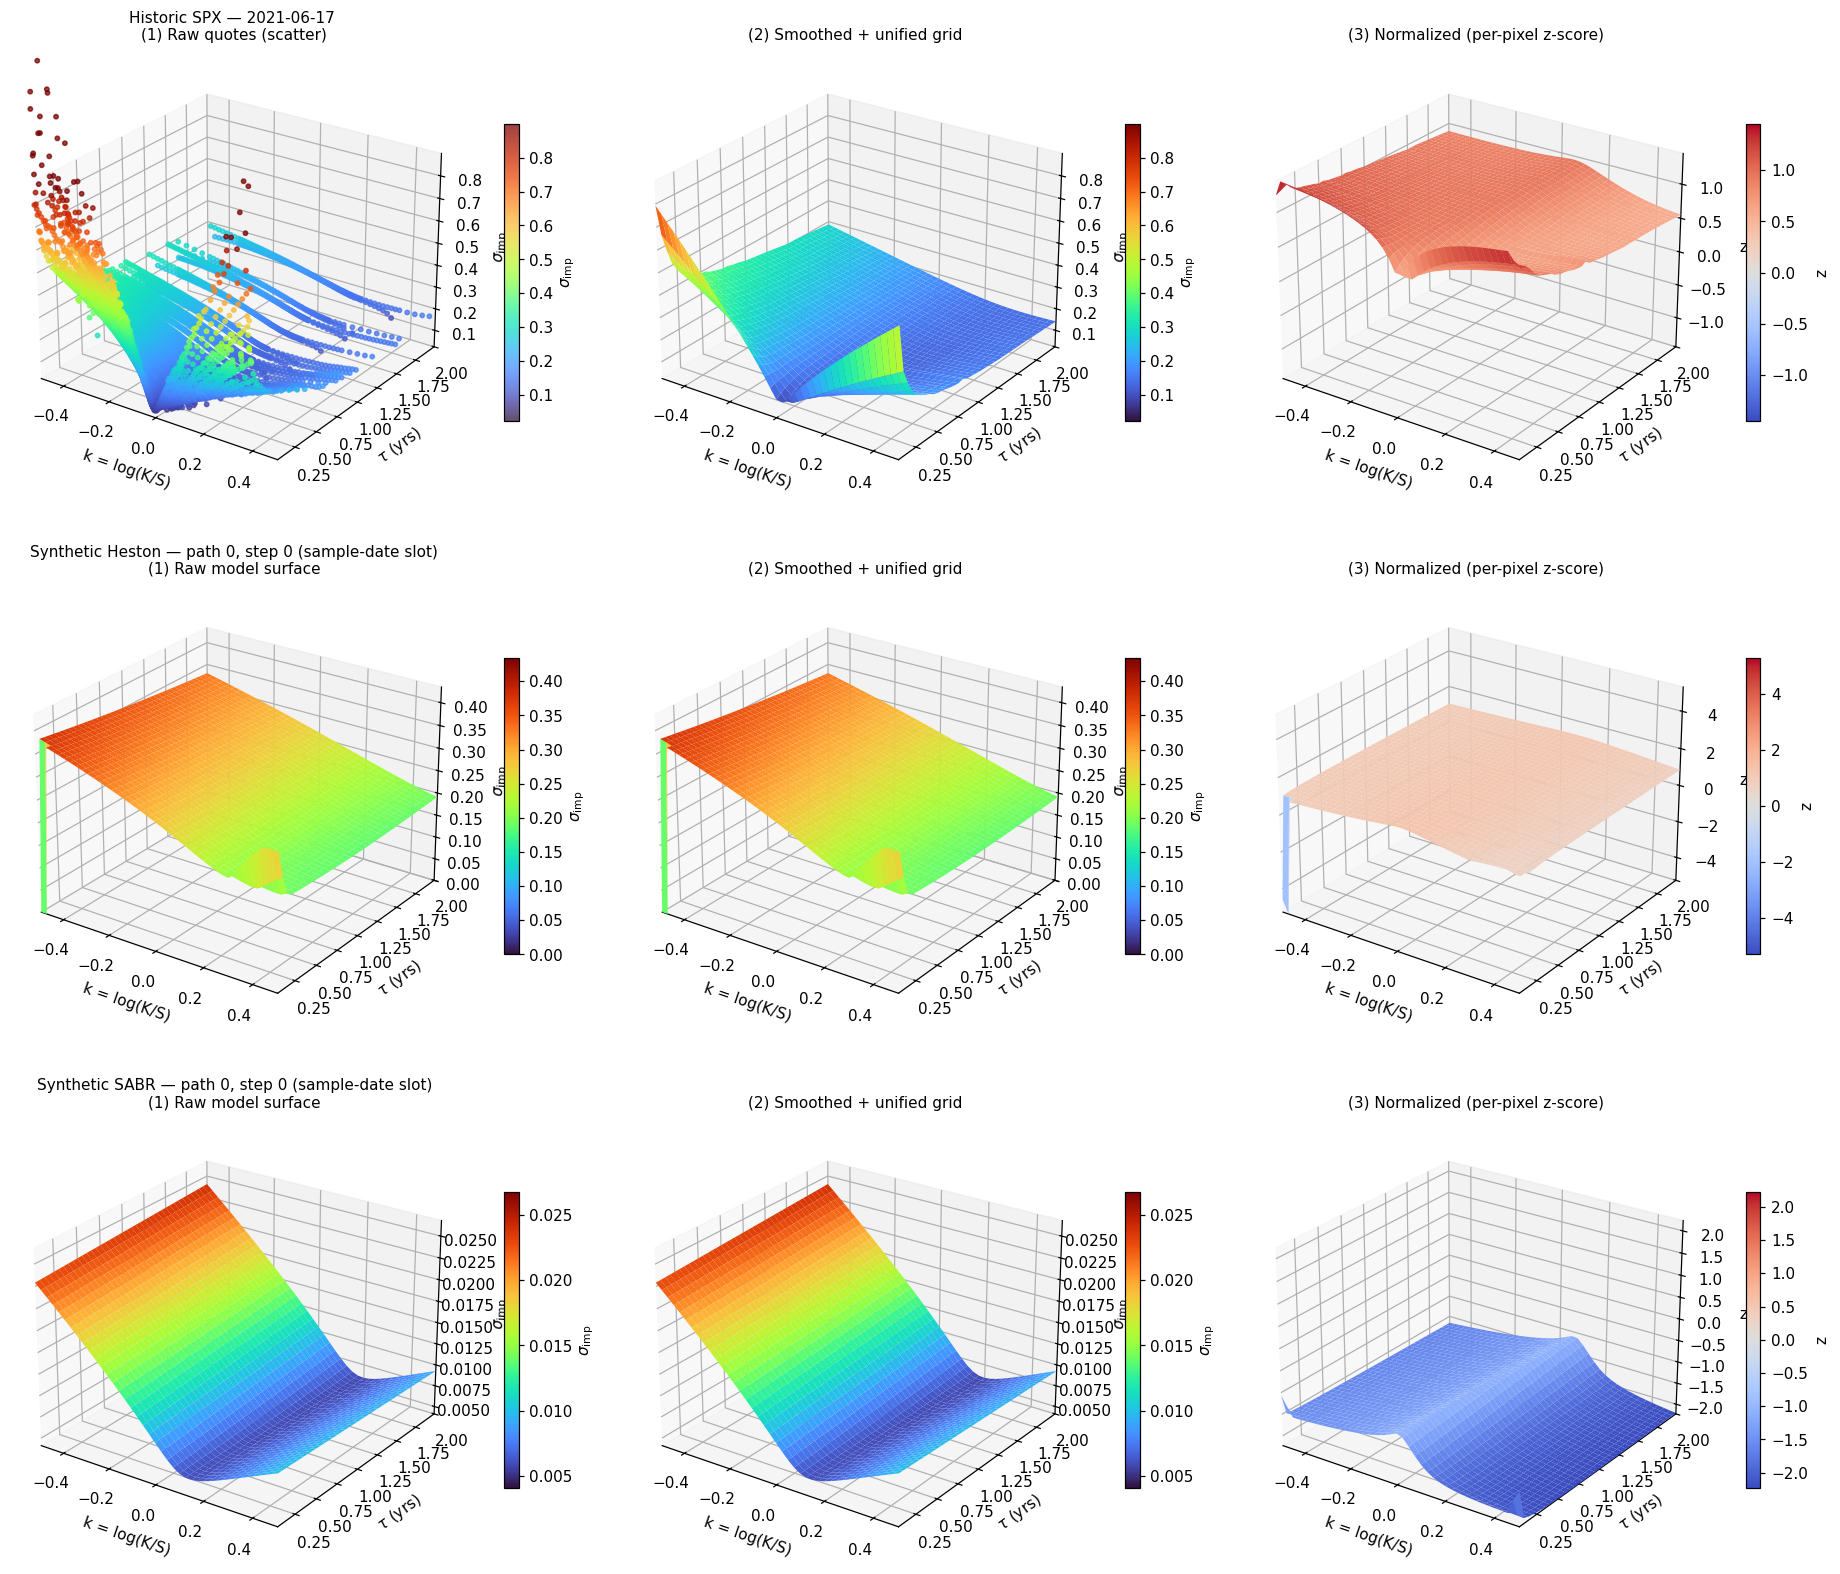

In [30]:
fig = plt.figure(figsize=(17, 5.2 * len(bundles)))

for row, b in enumerate(bundles):
    iv_vmin, iv_vmax = _iv_scale(b)
    z_vmin, z_vmax = _z_scale(b)

    ax1 = fig.add_subplot(len(bundles), 3, row * 3 + 1, projection="3d")
    if b.raw_mode == "scatter":
        sc = ax1.scatter(
            b.raw_k,
            b.raw_tau,
            b.raw_iv,
            c=b.raw_iv,
            cmap=CMAP_IV,
            s=8,
            alpha=0.75,
            vmin=iv_vmin,
            vmax=iv_vmax,
        )
        fig.colorbar(sc, ax=ax1, shrink=0.55, pad=0.08, label=r"$\sigma_{\mathrm{imp}}$")
        ax1.set_title(f"{b.title}\n(1) Raw quotes (scatter)", fontsize=10)
    else:
        surf = ax1.plot_surface(
            KK, TT, b.raw_iv, cmap=CMAP_IV, edgecolor="none", vmin=iv_vmin, vmax=iv_vmax, antialiased=True
        )
        fig.colorbar(surf, ax=ax1, shrink=0.55, pad=0.08, label=r"$\sigma_{\mathrm{imp}}$")
        ax1.set_title(f"{b.title}\n(1) Raw model surface", fontsize=10)
    _label_3d(ax1)
    ax1.set_zlabel(r"$\sigma_{\mathrm{imp}}$")
    ax1.set_zlim(iv_vmin, iv_vmax)

    ax2 = fig.add_subplot(len(bundles), 3, row * 3 + 2, projection="3d")
    surf = ax2.plot_surface(
        KK, TT, b.smoothed, cmap=CMAP_IV, edgecolor="none", vmin=iv_vmin, vmax=iv_vmax, antialiased=True
    )
    fig.colorbar(surf, ax=ax2, shrink=0.55, pad=0.08, label=r"$\sigma_{\mathrm{imp}}$")
    ax2.set_title("(2) Smoothed + unified grid", fontsize=10)
    _label_3d(ax2)
    ax2.set_zlabel(r"$\sigma_{\mathrm{imp}}$")
    ax2.set_zlim(iv_vmin, iv_vmax)

    ax3 = fig.add_subplot(len(bundles), 3, row * 3 + 3, projection="3d")
    surf = ax3.plot_surface(
        KK, TT, b.normalized, cmap=CMAP_Z, edgecolor="none", vmin=z_vmin, vmax=z_vmax, antialiased=True
    )
    fig.colorbar(surf, ax=ax3, shrink=0.55, pad=0.08, label="z")
    ax3.set_title("(3) Normalized (per-pixel z-score)", fontsize=10)
    _label_3d(ax3)
    ax3.set_zlabel("z")
    ax3.set_zlim(z_vmin, z_vmax)

fig.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig("pipeline_3d.pdf", bbox_inches='tight')
plt.show()

### Heatmaps

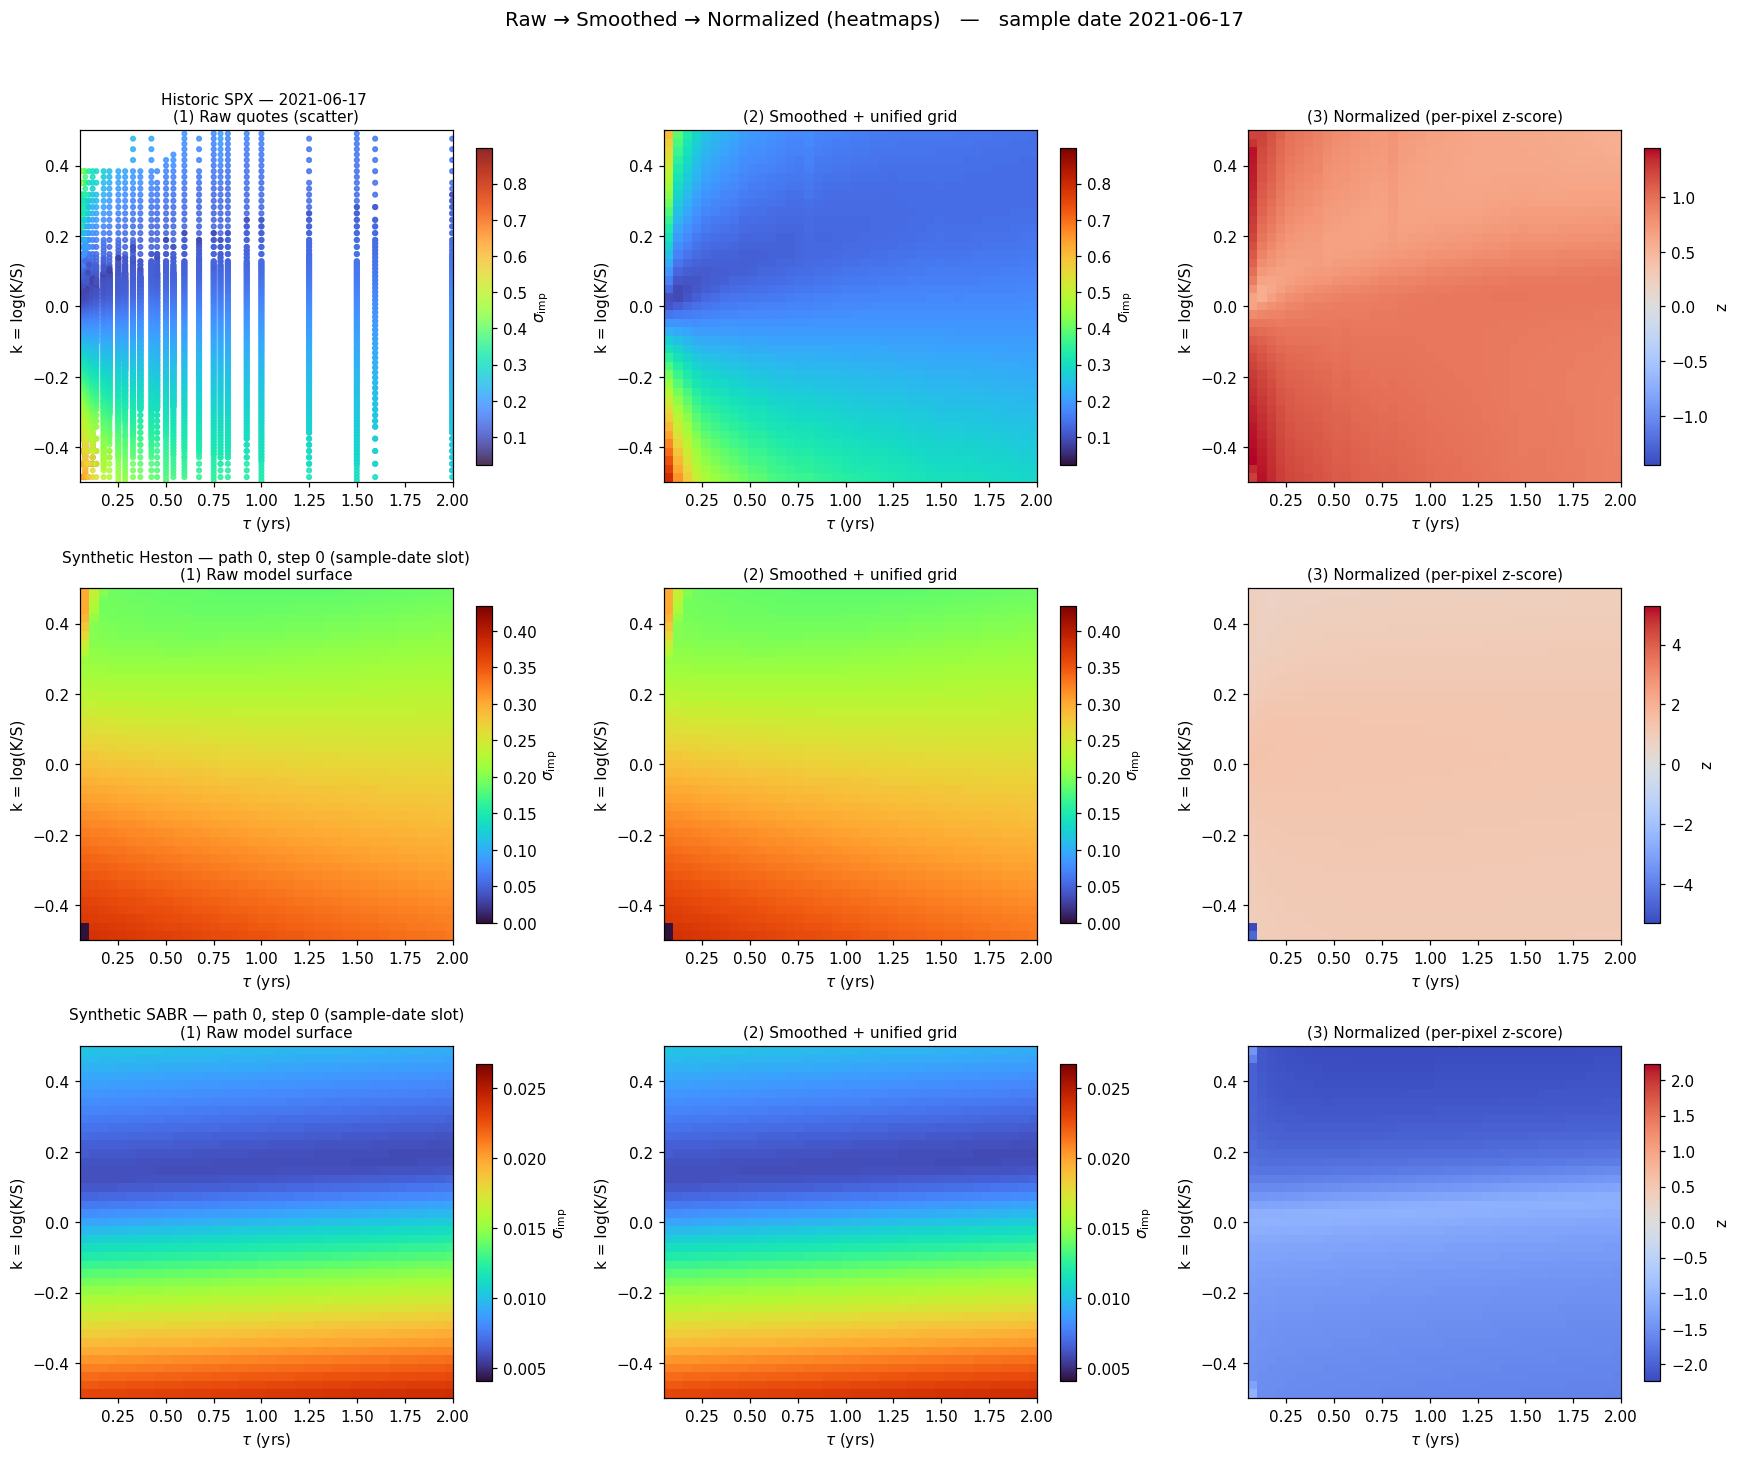

In [31]:
fig, axes = plt.subplots(len(bundles), 3, figsize=(16, 4.5 * len(bundles)))
if len(bundles) == 1:
    axes = np.atleast_2d(axes)
fig.suptitle(f"Raw → Smoothed → Normalized (heatmaps)   —   sample date {SAMPLE_DATE.date()}", fontsize=13)

for row, b in enumerate(bundles):
    iv_vmin, iv_vmax = _iv_scale(b)
    z_vmin, z_vmax = _z_scale(b)

    ax1 = axes[row, 0]
    if b.raw_mode == "scatter":
        sc = ax1.scatter(b.raw_tau, b.raw_k, c=b.raw_iv, cmap=CMAP_IV, s=9, alpha=0.85, vmin=iv_vmin, vmax=iv_vmax)
        fig.colorbar(sc, ax=ax1, shrink=0.9, label=r"$\sigma_{\mathrm{imp}}$")
        ax1.set_title(f"{b.title}\n(1) Raw quotes (scatter)", fontsize=10)
    else:
        im = ax1.imshow(
            b.raw_iv, origin="lower", aspect="auto", extent=HEAT_EXTENT, cmap=CMAP_IV, vmin=iv_vmin, vmax=iv_vmax
        )
        fig.colorbar(im, ax=ax1, shrink=0.9, label=r"$\sigma_{\mathrm{imp}}$")
        ax1.set_title(f"{b.title}\n(1) Raw model surface", fontsize=10)
    _label_heat(ax1)

    ax2 = axes[row, 1]
    im = ax2.imshow(
        b.smoothed, origin="lower", aspect="auto", extent=HEAT_EXTENT, cmap=CMAP_IV, vmin=iv_vmin, vmax=iv_vmax
    )
    fig.colorbar(im, ax=ax2, shrink=0.9, label=r"$\sigma_{\mathrm{imp}}$")
    ax2.set_title("(2) Smoothed + unified grid", fontsize=10)
    _label_heat(ax2)

    ax3 = axes[row, 2]
    im = ax3.imshow(
        b.normalized, origin="lower", aspect="auto", extent=HEAT_EXTENT, cmap=CMAP_Z, vmin=z_vmin, vmax=z_vmax
    )
    fig.colorbar(im, ax=ax3, shrink=0.9, label="z")
    ax3.set_title("(3) Normalized (per-pixel z-score)", fontsize=10)
    _label_heat(ax3)

fig.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig("pipeline_heatmap.pdf", bbox_inches='tight')
plt.show()

### Normalized to Denormalized

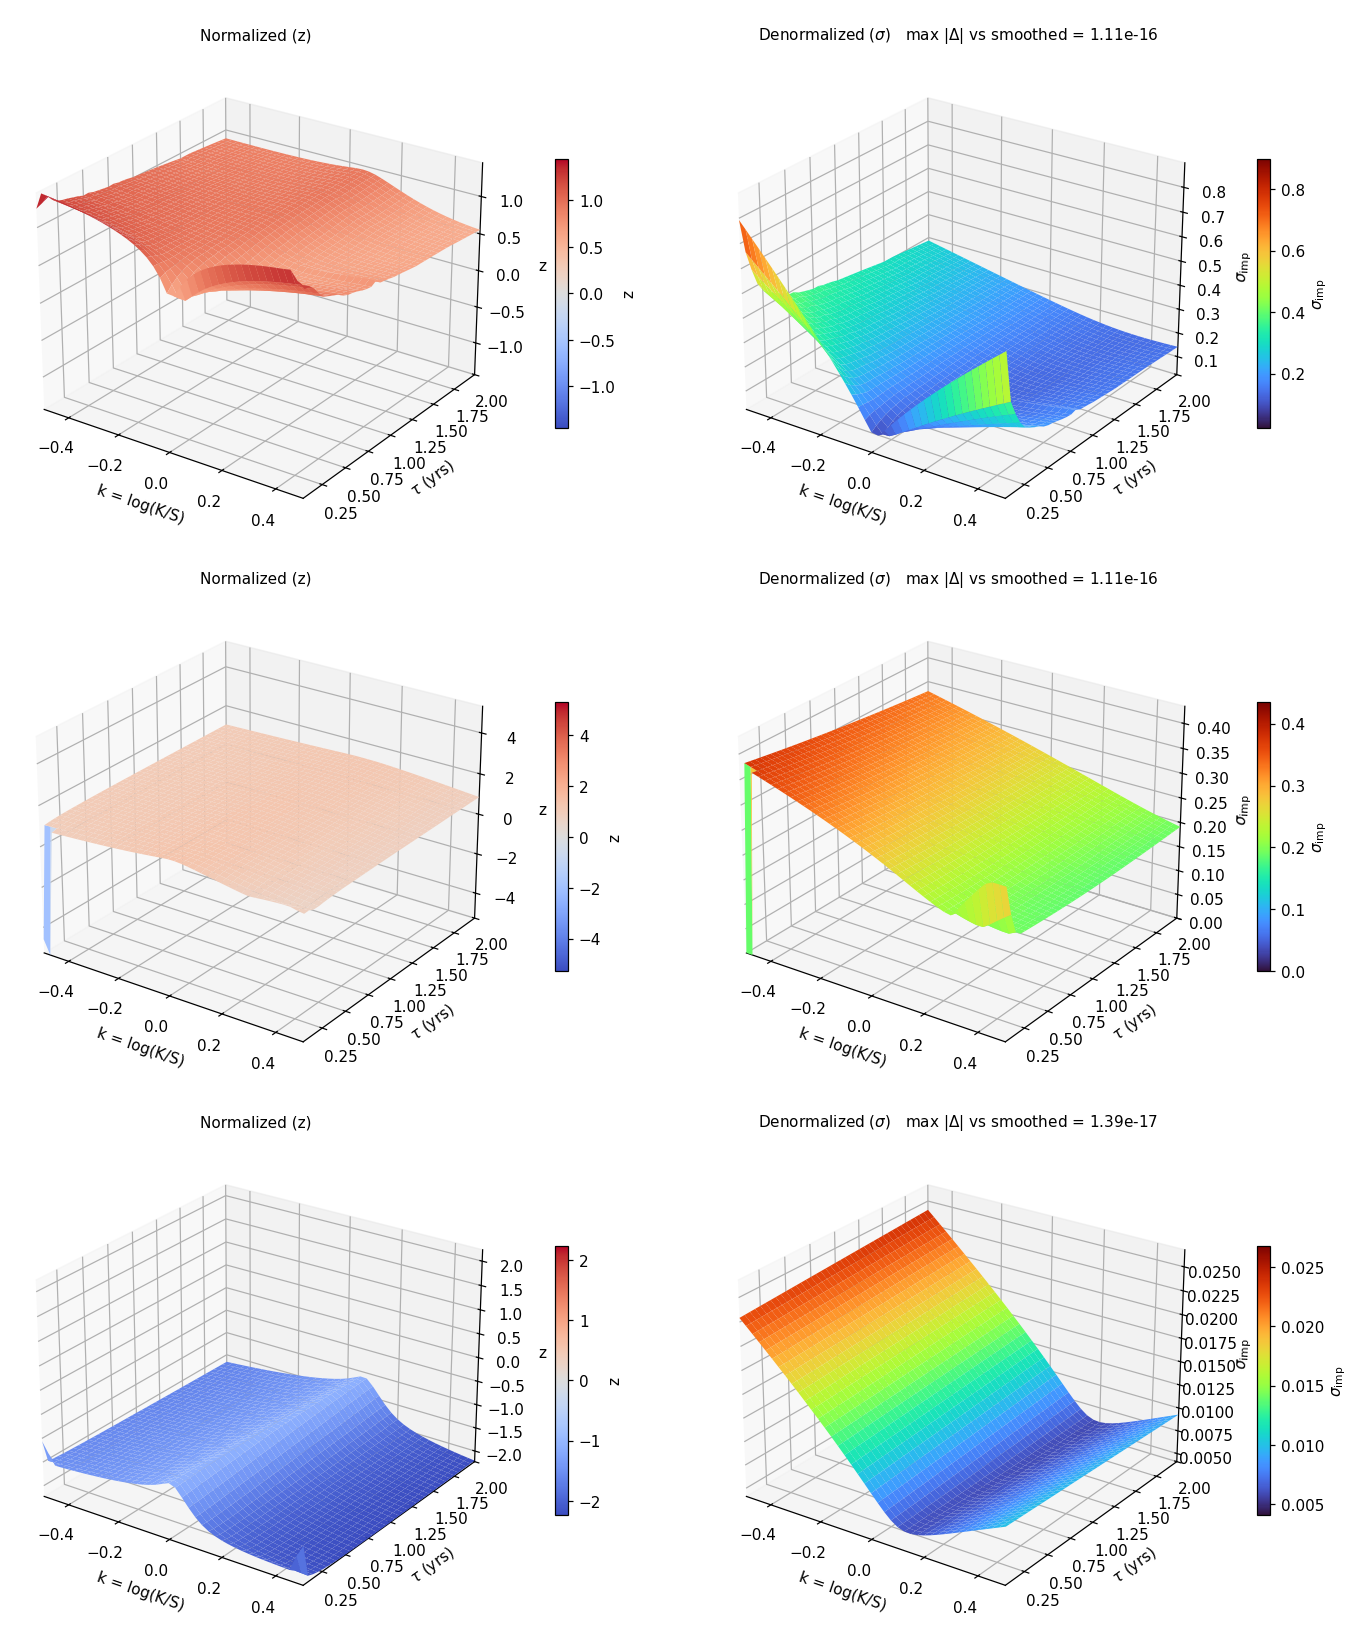

In [32]:
fig = plt.figure(figsize=(13, 5.2 * len(bundles)))

for row, b in enumerate(bundles):
    iv_vmin, iv_vmax = _iv_scale(b)
    z_vmin, z_vmax = _z_scale(b)

    ax_left = fig.add_subplot(len(bundles), 2, row * 2 + 1, projection="3d")
    surf = ax_left.plot_surface(
        KK, TT, b.normalized, cmap=CMAP_Z, edgecolor="none", vmin=z_vmin, vmax=z_vmax, antialiased=True
    )
    fig.colorbar(surf, ax=ax_left, shrink=0.55, pad=0.08, label="z")
    ax_left.set_title("\nNormalized (z)", fontsize=10)
    _label_3d(ax_left)
    ax_left.set_zlabel("z")
    ax_left.set_zlim(z_vmin, z_vmax)

    ax_right = fig.add_subplot(len(bundles), 2, row * 2 + 2, projection="3d")
    surf = ax_right.plot_surface(
        KK, TT, b.denormalized, cmap=CMAP_IV, edgecolor="none", vmin=iv_vmin, vmax=iv_vmax, antialiased=True
    )
    fig.colorbar(surf, ax=ax_right, shrink=0.55, pad=0.08, label=r"$\sigma_{\mathrm{imp}}$")
    diff = float(np.nanmax(np.abs(b.denormalized - b.smoothed)))
    ax_right.set_title(f"Denormalized ($\\sigma$)   max |Δ| vs smoothed = {diff:.2e}", fontsize=10)
    _label_3d(ax_right)
    ax_right.set_zlabel(r"$\sigma_{\mathrm{imp}}$")
    ax_right.set_zlim(iv_vmin, iv_vmax)

fig.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig("pipeline_normalization_roundtrip_3d.pdf", bbox_inches='tight')
plt.show()

### Heatmaps

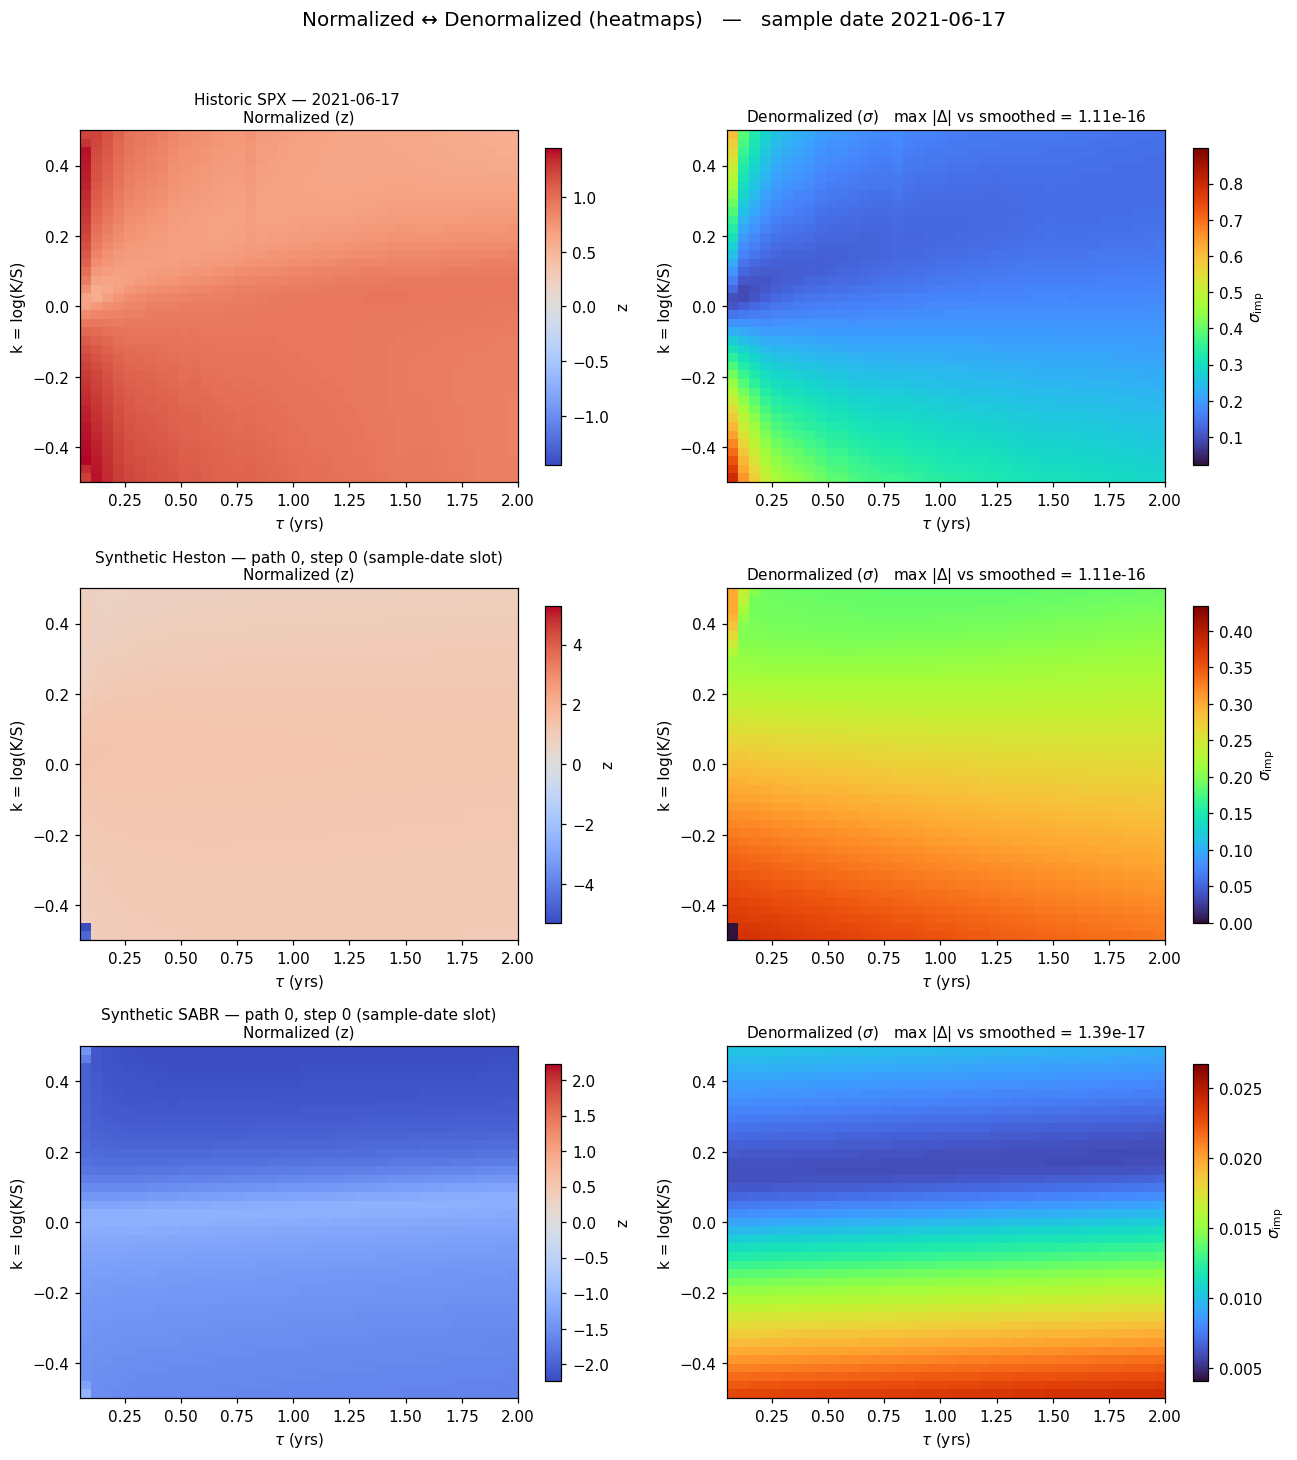

In [33]:
fig, axes = plt.subplots(len(bundles), 2, figsize=(12, 4.5 * len(bundles)))
if len(bundles) == 1:
    axes = np.atleast_2d(axes)
fig.suptitle(f"Normalized ↔ Denormalized (heatmaps)   —   sample date {SAMPLE_DATE.date()}", fontsize=13)

for row, b in enumerate(bundles):
    iv_vmin, iv_vmax = _iv_scale(b)
    z_vmin, z_vmax = _z_scale(b)

    ax_left = axes[row, 0]
    im = ax_left.imshow(
        b.normalized, origin="lower", aspect="auto", extent=HEAT_EXTENT, cmap=CMAP_Z, vmin=z_vmin, vmax=z_vmax
    )
    fig.colorbar(im, ax=ax_left, shrink=0.9, label="z")
    ax_left.set_title(f"{b.title}\nNormalized (z)", fontsize=10)
    _label_heat(ax_left)

    ax_right = axes[row, 1]
    im = ax_right.imshow(
        b.denormalized, origin="lower", aspect="auto", extent=HEAT_EXTENT, cmap=CMAP_IV, vmin=iv_vmin, vmax=iv_vmax
    )
    fig.colorbar(im, ax=ax_right, shrink=0.9, label=r"$\sigma_{\mathrm{imp}}$")
    diff = float(np.nanmax(np.abs(b.denormalized - b.smoothed)))
    ax_right.set_title(f"Denormalized ($\\sigma$)   max |Δ| vs smoothed = {diff:.2e}", fontsize=10)
    _label_heat(ax_right)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()